<a href="https://colab.research.google.com/github/bertramwooster/deep-learning-with-python-notebooks/blob/master/chapter05_fundamentals-of-ml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This is a companion notebook for the book [Deep Learning with Python, Third Edition](https://www.manning.com/books/deep-learning-with-python-third-edition). For readability, it only contains runnable code blocks and section titles, and omits everything else in the book: text paragraphs, figures, and pseudocode.

**If you want to be able to follow what's going on, I recommend reading the notebook side by side with your copy of the book.**

The book's contents are available online at [deeplearningwithpython.io](https://deeplearningwithpython.io).

In [1]:
!pip install keras keras-hub --upgrade -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 947.9/947.9 kB 47.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
keras-nlp 0.21.1 requires keras-hub==0.21.1, but you have keras-hub 0.22.2 which is incompatible.


In [2]:
import os
os.environ["KERAS_BACKEND"] = "jax"

In [3]:
# @title
import os
from IPython.core.magic import register_cell_magic

@register_cell_magic
def backend(line, cell):
    current, required = os.environ.get("KERAS_BACKEND", ""), line.split()[-1]
    if current == required:
        get_ipython().run_cell(cell)
    else:
        print(
            f"This cell requires the {required} backend. To run it, change KERAS_BACKEND to "
            f"\"{required}\" at the top of the notebook, restart the runtime, and rerun the notebook."
        )

## Fundamentals of machine learning

### Generalization: The goal of machine learning

#### Underfitting and overfitting

##### Noisy training data

##### Ambiguous features

##### Rare features and spurious correlations

In [4]:
from keras.datasets import mnist
import numpy as np

(train_images, train_labels), _ = mnist.load_data()
train_images = train_images.reshape((60000, 28 * 28))
train_images = train_images.astype("float32") / 255

train_images_with_noise_channels = np.concatenate(
    [train_images, np.random.random((len(train_images), 784))], axis=1
)

train_images_with_zeros_channels = np.concatenate(
    [train_images, np.zeros((len(train_images), 784))], axis=1
)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
len(train_images_with_noise_channels[0])

1568

In [5]:
import keras
from keras import layers

def get_model():
    model = keras.Sequential(
        [
            layers.Dense(512, activation="relu"),
            layers.Dense(10, activation="softmax"),
        ]
    )
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

model = get_model()
history_noise = model.fit(
    train_images_with_noise_channels,
    train_labels,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
)

model = get_model()
history_zeros = model.fit(
    train_images_with_zeros_channels,
    train_labels,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 17s 40ms/step - accuracy: 0.8694 - loss: 0.4320 - val_accuracy: 0.9243 - val_loss: 0.2588
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9307 - loss: 0.2325 - val_accuracy: 0.9408 - val_loss: 0.2002
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.9528 - loss: 0.1564 - val_accuracy: 0.9466 - val_loss: 0.1825
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9675 - loss: 0.1103 - val_accuracy: 0.9559 - val_loss: 0.1491
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9778 - loss: 0.0776 - val_accuracy: 0.9524 - val_loss: 0.1593
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9831 - loss: 0.0571 - val_accuracy: 0.9655 - val_loss: 0.1182
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9886 - loss: 0.0414 - val_accuracy: 0.9599 - val_loss: 0.1316
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9931 - loss: 0.0268 - val_acc

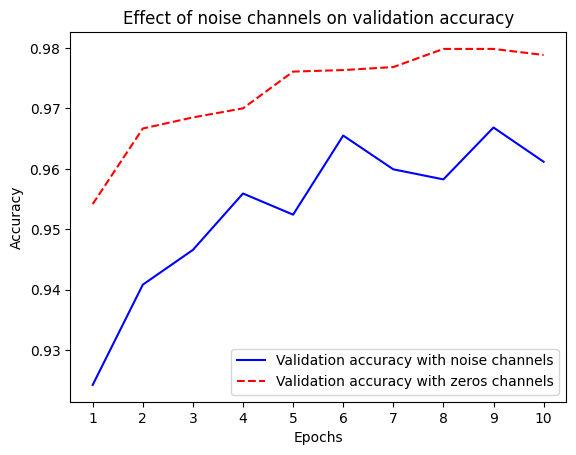

In [6]:
import matplotlib.pyplot as plt

val_acc_noise = history_noise.history["val_accuracy"]
val_acc_zeros = history_zeros.history["val_accuracy"]
epochs = range(1, 11)
plt.plot(
    epochs,
    val_acc_noise,
    "b-",
    label="Validation accuracy with noise channels",
)
plt.plot(
    epochs,
    val_acc_zeros,
    "r--",
    label="Validation accuracy with zeros channels",
)
plt.title("Effect of noise channels on validation accuracy")
plt.xlabel("Epochs")
plt.xticks(epochs)
plt.ylabel("Accuracy")
plt.legend()
plt.show()

### Feature Correlation and Selection

We can calculate the correlation between each feature in the training data and the training labels. This can help us understand which features are most relevant for predicting the labels.

In [ ]:
# Calculate correlations
correlations = np.corrcoef(train_images.T, train_labels)

# The correlation matrix includes correlations between all pairs of features and labels.
# We are interested in the correlations between features and labels.
# The last row (or column) contains the correlations with the labels.
feature_label_correlations = correlations[:-1, -1]

# Print the correlations
print("Correlation between each feature and the labels:")
len(feature_label_correlations)

Correlation between each feature and the labels:


785

Now we can select a subset of features that have the highest absolute correlation with the labels.

In [ ]:
# Get the indices of features sorted by absolute correlation in descending order
sorted_indices = np.argsort(np.abs(feature_label_correlations))[::-1]

# Define the number of top features to keep (e.g., top 100)
num_top_features = 100

# Select the indices of the top features
top_feature_indices = sorted_indices[:num_top_features]

# Create a new training set with only the top features
train_images_top_features = train_images[:, top_feature_indices]

print(f"\nShape of the original training data: {train_images.shape}")
print(f"Shape of the training data with top {num_top_features} features: {train_images_top_features.shape}")

Now you can train a model using `train_images_top_features` instead of the original `train_images` to see how feature selection affects performance.

#### The nature of generalization in deep learning

In [7]:
(train_images, train_labels), _ = mnist.load_data()
train_images = train_images.reshape((60000, 28 * 28))
train_images = train_images.astype("float32") / 255

random_train_labels = train_labels[:]
np.random.shuffle(random_train_labels)
kk = 100
model = keras.Sequential(
    [
        layers.Dense(512, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ]
)
model.compile(
    optimizer="rmsprop",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
history_random_shuffle = model.fit(
    train_images,
    random_train_labels,
    epochs=kk,
    batch_size=128,
    validation_split=0.2,
)

Epoch 1/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.1038 - loss: 2.3161 - val_accuracy: 0.1031 - val_loss: 2.3049
Epoch 2/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.1183 - loss: 2.2983 - val_accuracy: 0.0985 - val_loss: 2.3143
Epoch 3/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.1283 - loss: 2.2898 - val_accuracy: 0.1006 - val_loss: 2.3212
Epoch 4/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.1414 - loss: 2.2787 - val_accuracy: 0.0970 - val_loss: 2.3275
Epoch 5/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.1528 - loss: 2.2615 - val_accuracy: 0.1018 - val_loss: 2.3343
Epoch 6/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.1688 - loss: 2.2415 - val_accuracy: 0.1002 - val_loss: 2.3560
Epoch 7/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.1807 - loss: 2.2178 - val_accuracy: 0.1054 - val_loss: 2.3741
Epoch 8/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.1957 - loss: 2.1926 - val_acc

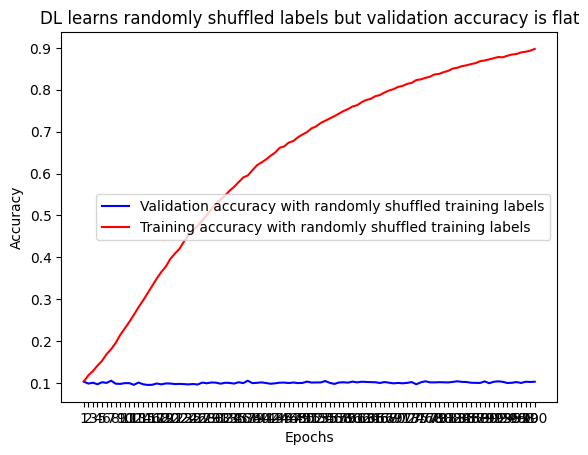

In [8]:
import matplotlib.pyplot as plt
acc_noise = history_random_shuffle.history["accuracy"]
val_acc_noise = history_random_shuffle.history["val_accuracy"]
epochs = range(1, kk + 1)
plt.plot(
    epochs,
    val_acc_noise,
    "b-",
    label="Validation accuracy with randomly shuffled training labels",
)
plt.plot(
    epochs,
    acc_noise,
    "r-",
    label="Training accuracy with randomly shuffled training labels",
)
plt.title("DL learns randomly shuffled labels but validation accuracy is flat")
plt.xlabel("Epochs")
plt.xticks(epochs)
plt.ylabel("Accuracy")
plt.legend()
plt.show()

##### The manifold hypothesis

##### Interpolation as a source of generalization

##### Why deep learning works

##### Training data is paramount

### Evaluating machine-learning models

#### Training, validation, and test sets

##### Simple hold-out validation

##### K-fold validation

##### Iterated K-fold validation with shuffling

#### Beating a common-sense baseline

#### Things to keep in mind about model evaluation

### Improving model fit

#### Tuning key gradient descent parameters

In [9]:
(train_images, train_labels), _ = mnist.load_data()
train_images = train_images.reshape((60000, 28 * 28))
train_images = train_images.astype("float32") / 255

model = keras.Sequential(
    [
        layers.Dense(512, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ]
)
model.compile(
    optimizer=keras.optimizers.RMSprop(learning_rate=1.0),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
model.fit(
    train_images, train_labels, epochs=10, batch_size=128, validation_split=0.2
)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.0992 - loss: 14.4872 - val_accuracy: 0.0997 - val_loss: 14.5117
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.0992 - loss: 14.5191 - val_accuracy: 0.0997 - val_loss: 14.5117
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.0992 - loss: 14.5191 - val_accuracy: 0.0997 - val_loss: 14.5117
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.0992 - loss: 14.5191 - val_accuracy: 0.0997 - val_loss: 14.5117
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.0992 - loss: 14.5191 - val_accuracy: 0.0997 - val_loss: 14.5117
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.0992 - loss: 14.5191 - val_accuracy: 0.0997 - val_loss: 14.5117
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.0992 - loss: 14.5191 - val_accuracy: 0.0997 - val_loss: 14.5117
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.0992 - loss: 14.5191 

In [10]:
model = keras.Sequential(
    [
        layers.Dense(512, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ]
)
model.compile(
    optimizer=keras.optimizers.RMSprop(learning_rate=1e-2),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
model.fit(
    train_images, train_labels, epochs=10, batch_size=128, validation_split=0.2
)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.9092 - loss: 0.3880 - val_accuracy: 0.9593 - val_loss: 0.1409
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9643 - loss: 0.1288 - val_accuracy: 0.9686 - val_loss: 0.1203
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9736 - loss: 0.0972 - val_accuracy: 0.9672 - val_loss: 0.1459
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9792 - loss: 0.0840 - val_accuracy: 0.9697 - val_loss: 0.1584
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9818 - loss: 0.0748 - val_accuracy: 0.9678 - val_loss: 0.1922
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9841 - loss: 0.0666 - val_accuracy: 0.9647 - val_loss: 0.2066
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9868 - loss: 0.0578 - val_accuracy: 0.9696 - val_loss: 0.1943
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9890 - loss: 0.0537 - val_accuracy: 0

#### Using better architecture priors

#### Increasing model capacity

In [11]:
model = keras.Sequential([layers.Dense(10, activation="softmax")])
model.compile(
    optimizer="rmsprop",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
history_small_model = model.fit(
    train_images, train_labels, epochs=20, batch_size=128, validation_split=0.2
)

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8341 - loss: 0.6733 - val_accuracy: 0.9008 - val_loss: 0.3621
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9031 - loss: 0.3537 - val_accuracy: 0.9145 - val_loss: 0.3091
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9115 - loss: 0.3178 - val_accuracy: 0.9183 - val_loss: 0.2932
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9160 - loss: 0.3019 - val_accuracy: 0.9203 - val_loss: 0.2841
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9180 - loss: 0.2921 - val_accuracy: 0.9229 - val_loss: 0.2783
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9202 - loss: 0.2857 - val_accuracy: 0.9259 - val_loss: 0.2739
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9215 - loss: 0.2804 - val_accuracy: 0.9250 - val_loss: 0.2715
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9227 - loss: 0.2765 - val_accuracy: 0.

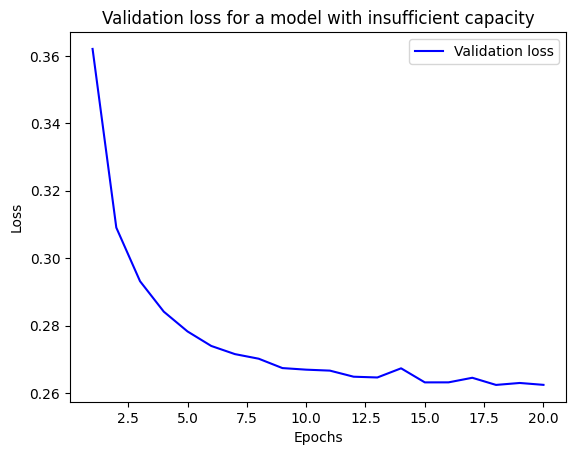

In [12]:
import matplotlib.pyplot as plt

val_loss = history_small_model.history["val_loss"]
epochs = range(1, 21)
plt.plot(epochs, val_loss, "b-", label="Validation loss")
plt.title("Validation loss for a model with insufficient capacity")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [13]:
model = keras.Sequential(
    [
        layers.Dense(128, activation="relu"),
        layers.Dense(128, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ]
)
model.compile(
    optimizer="rmsprop",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
history_large_model = model.fit(
    train_images,
    train_labels,
    epochs=20,
    batch_size=128,
    validation_split=0.2,
)

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9010 - loss: 0.3387 - val_accuracy: 0.9465 - val_loss: 0.1801
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9572 - loss: 0.1439 - val_accuracy: 0.9612 - val_loss: 0.1317
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9695 - loss: 0.0995 - val_accuracy: 0.9662 - val_loss: 0.1130
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9778 - loss: 0.0726 - val_accuracy: 0.9711 - val_loss: 0.1004
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9830 - loss: 0.0572 - val_accuracy: 0.9729 - val_loss: 0.0991
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9854 - loss: 0.0455 - val_accuracy: 0.9754 - val_loss: 0.0852
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9886 - loss: 0.0365 - val_accuracy: 0.9760 - val_loss: 0.0870
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9910 - loss: 0.0291 - val_accuracy: 0

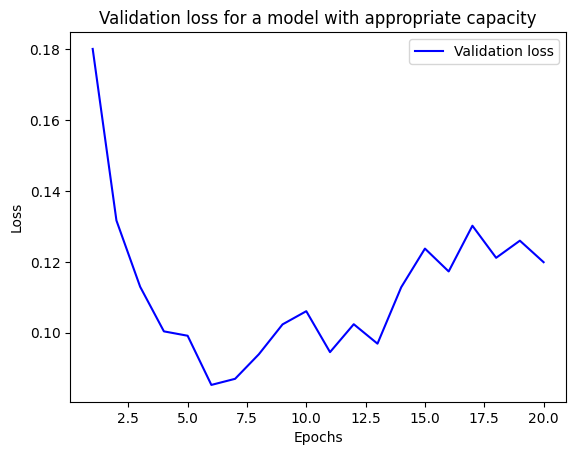

In [14]:
val_loss = history_large_model.history["val_loss"]
epochs = range(1, 21)
plt.plot(epochs, val_loss, "b-", label="Validation loss")
plt.title("Validation loss for a model with appropriate capacity")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [15]:
model = keras.Sequential(
    [
        layers.Dense(2048, activation="relu"),
        layers.Dense(2048, activation="relu"),
        layers.Dense(2048, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ]
)
model.compile(
    optimizer="rmsprop",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
history_very_large_model = model.fit(
    train_images,
    train_labels,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
)

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 164s 108ms/step - accuracy: 0.9252 - loss: 0.2561 - val_accuracy: 0.9582 - val_loss: 0.1689
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 161s 106ms/step - accuracy: 0.9687 - loss: 0.1173 - val_accuracy: 0.9606 - val_loss: 0.1569
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 164s 109ms/step - accuracy: 0.9787 - loss: 0.0879 - val_accuracy: 0.9730 - val_loss: 0.1155
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 160s 106ms/step - accuracy: 0.9837 - loss: 0.0694 - val_accuracy: 0.9733 - val_loss: 0.1357
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 159s 106ms/step - accuracy: 0.9866 - loss: 0.0558 - val_accuracy: 0.9778 - val_loss: 0.1344
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 159s 106ms/step - accuracy: 0.9886 - loss: 0.0497 - val_accuracy: 0.9757 - val_loss: 0.1612
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 159s 106ms/step - accuracy: 0.9906 - loss: 0.0430 - val_accuracy: 0.9793 - val_loss: 0.1401
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 162s 108ms/step - ac

KeyboardInterrupt: 

In [ ]:
val_loss = history_very_large_model.history["val_loss"]
epochs = range(1, 21)
plt.plot(epochs, val_loss, "b-", label="Validation loss")
plt.title("Validation loss for a model with too much capacity")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

### Improving generalization

#### Dataset curation

#### Feature engineering

#### Using early stopping

#### Regularizing your model

##### Reducing the network's size

In [16]:
from keras.datasets import imdb

(train_data, train_labels), _ = imdb.load_data(num_words=10000)

def vectorize_sequences(sequences, dimension=10000):
    results = np.zeros((len(sequences), dimension))
    for i, sequence in enumerate(sequences):
        results[i, sequence] = 1.0
    return results

train_data = vectorize_sequences(train_data)

model = keras.Sequential(
    [
        layers.Dense(16, activation="relu"),
        layers.Dense(16, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ]
)
model.compile(
    optimizer="rmsprop",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)
history_original = model.fit(
    train_data,
    train_labels,
    epochs=20,
    batch_size=512,
    validation_split=0.4,
)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 132ms/step - accuracy: 0.7625 - loss: 0.5486 - val_accuracy: 0.8518 - val_loss: 0.4245
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.8913 - loss: 0.3409 - val_accuracy: 0.8737 - val_loss: 0.3356
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.9172 - loss: 0.2527 - val_accuracy: 0.8802 - val_loss: 0.3021
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.9327 - loss: 0.2050 - val_accuracy: 0.8905 - val_loss: 0.2774
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.9473 - loss: 0.1689 - val_accuracy: 0.8889 - val_loss: 0.2761
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.9567 - loss: 0.1416 - val_accuracy: 0.8803 - val_loss: 0.2990
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.9640 - loss: 0.1185 - val_accuracy: 0.8782 - val_loss: 0.3068
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accura

In [17]:
model = keras.Sequential(
    [
        layers.Dense(4, activation="relu"),
        layers.Dense(4, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ]
)
model.compile(
    optimizer="rmsprop",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)
history_smaller_model = model.fit(
    train_data,
    train_labels,
    epochs=20,
    batch_size=512,
    validation_split=0.4,
)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 7s 175ms/step - accuracy: 0.6005 - loss: 0.6766 - val_accuracy: 0.6065 - val_loss: 0.6583
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.6743 - loss: 0.6428 - val_accuracy: 0.6638 - val_loss: 0.6278
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.7325 - loss: 0.6109 - val_accuracy: 0.7274 - val_loss: 0.5975
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.7722 - loss: 0.5771 - val_accuracy: 0.7554 - val_loss: 0.5670
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.8053 - loss: 0.5452 - val_accuracy: 0.8101 - val_loss: 0.5401
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.8336 - loss: 0.5169 - val_accuracy: 0.8239 - val_loss: 0.5169
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.8533 - loss: 0.4915 - val_accuracy: 0.8196 - val_loss: 0.4985
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.8687 - loss: 0.4689 - val_accuracy: 0.8376 - 

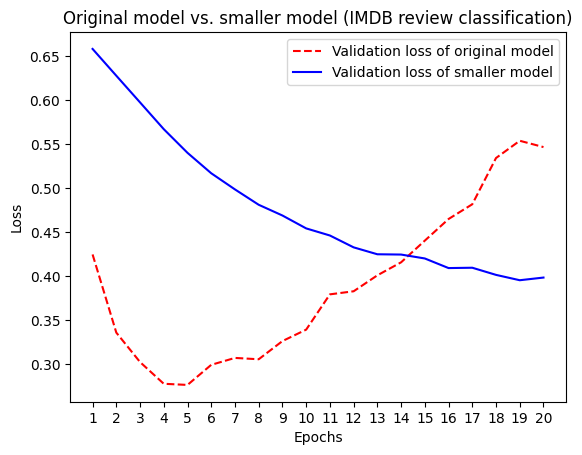

In [18]:
original_val_loss = history_original.history["val_loss"]
smaller_model_val_loss = history_smaller_model.history["val_loss"]
epochs = range(1, 21)
plt.plot(
    epochs,
    original_val_loss,
    "r--",
    label="Validation loss of original model",
)
plt.plot(
    epochs,
    smaller_model_val_loss,
    "b-",
    label="Validation loss of smaller model",
)
plt.title("Original model vs. smaller model (IMDB review classification)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.xticks(epochs)
plt.legend()
plt.show()

In [19]:
model = keras.Sequential(
    [
        layers.Dense(512, activation="relu"),
        layers.Dense(512, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ]
)
model.compile(
    optimizer="rmsprop",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)
history_larger_model = model.fit(
    train_data,
    train_labels,
    epochs=20,
    batch_size=512,
    validation_split=0.4,
)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 10s 331ms/step - accuracy: 0.7515 - loss: 0.5758 - val_accuracy: 0.8741 - val_loss: 0.3363
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 8s 265ms/step - accuracy: 0.8738 - loss: 0.3067 - val_accuracy: 0.7434 - val_loss: 0.5751
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 9s 285ms/step - accuracy: 0.9074 - loss: 0.2342 - val_accuracy: 0.8891 - val_loss: 0.2657
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 8s 278ms/step - accuracy: 0.9311 - loss: 0.1813 - val_accuracy: 0.8808 - val_loss: 0.3037
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 7s 239ms/step - accuracy: 0.9451 - loss: 0.1464 - val_accuracy: 0.8899 - val_loss: 0.2841
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 8s 280ms/step - accuracy: 0.9651 - loss: 0.0966 - val_accuracy: 0.8848 - val_loss: 0.3278
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 8s 280ms/step - accuracy: 0.9748 - loss: 0.0770 - val_accuracy: 0.8866 - val_loss: 0.3719
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 7s 236ms/step - accuracy: 0.9777 - loss: 0.0701 - val_accuracy: 0

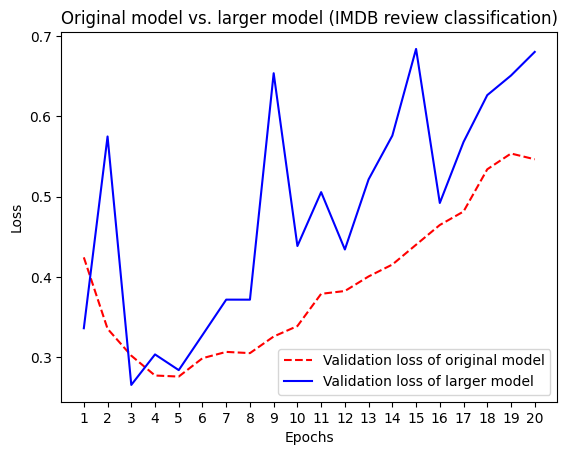

In [20]:
original_val_loss = history_original.history["val_loss"]
larger_model_val_loss = history_larger_model.history["val_loss"]
epochs = range(1, 21)
plt.plot(
    epochs,
    original_val_loss,
    "r--",
    label="Validation loss of original model",
)
plt.plot(
    epochs,
    larger_model_val_loss,
    "b-",
    label="Validation loss of larger model",
)
plt.title("Original model vs. larger model (IMDB review classification)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.xticks(epochs)
plt.legend()
plt.show()

##### Adding weight regularization

In [21]:
from keras.regularizers import l2

model = keras.Sequential(
    [
        layers.Dense(16, kernel_regularizer=l2(0.002), activation="relu"),
        layers.Dense(16, kernel_regularizer=l2(0.002), activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ]
)
model.compile(
    optimizer="rmsprop",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)
history_l2_reg = model.fit(
    train_data,
    train_labels,
    epochs=20,
    batch_size=512,
    validation_split=0.4,
)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 8s 211ms/step - accuracy: 0.7570 - loss: 0.6582 - val_accuracy: 0.8377 - val_loss: 0.5361
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.8819 - loss: 0.4557 - val_accuracy: 0.8466 - val_loss: 0.4514
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.9012 - loss: 0.3671 - val_accuracy: 0.8859 - val_loss: 0.3803
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.9184 - loss: 0.3176 - val_accuracy: 0.8760 - val_loss: 0.3802
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.9242 - loss: 0.2951 - val_accuracy: 0.8845 - val_loss: 0.3621
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.9317 - loss: 0.2750 - val_accuracy: 0.8657 - val_loss: 0.4007
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.9392 - loss: 0.2598 - val_accuracy: 0.8836 - val_loss: 0.3593
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.9421 - loss: 0.2517 - val_accuracy: 0.8802 - 

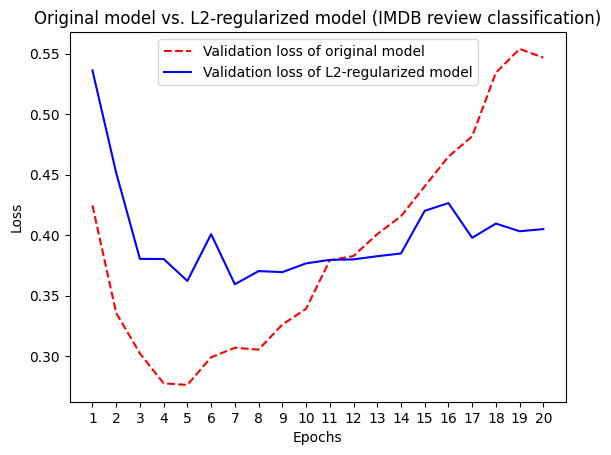

In [22]:
original_val_loss = history_original.history["val_loss"]
l2_val_loss = history_l2_reg.history["val_loss"]
epochs = range(1, 21)
plt.plot(
    epochs,
    original_val_loss,
    "r--",
    label="Validation loss of original model",
)
plt.plot(
    epochs,
    l2_val_loss,
    "b-",
    label="Validation loss of L2-regularized model",
)
plt.title(
    "Original model vs. L2-regularized model (IMDB review classification)"
)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.xticks(epochs)
plt.legend()
plt.show()

In [23]:
from keras import regularizers

regularizers.l1(0.001)
regularizers.l1_l2(l1=0.001, l2=0.001)

##### Adding dropout

In [24]:
model = keras.Sequential(
    [
        layers.Dense(16, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(16, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(1, activation="sigmoid"),
    ]
)
model.compile(
    optimizer="rmsprop",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)
history_dropout = model.fit(
    train_data,
    train_labels,
    epochs=20,
    batch_size=512,
    validation_split=0.4,
)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 7s 168ms/step - accuracy: 0.6280 - loss: 0.6374 - val_accuracy: 0.8445 - val_loss: 0.5174
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.7674 - loss: 0.5121 - val_accuracy: 0.8325 - val_loss: 0.4382
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.8232 - loss: 0.4327 - val_accuracy: 0.8795 - val_loss: 0.3651
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.8609 - loss: 0.3712 - val_accuracy: 0.8871 - val_loss: 0.3049
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.8835 - loss: 0.3196 - val_accuracy: 0.8920 - val_loss: 0.2831
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.9013 - loss: 0.2837 - val_accuracy: 0.8912 - val_loss: 0.2724
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.9138 - loss: 0.2535 - val_accuracy: 0.8902 - val_loss: 0.2773
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.9277 - loss: 0.2222 - val_accuracy: 0.8931 - 

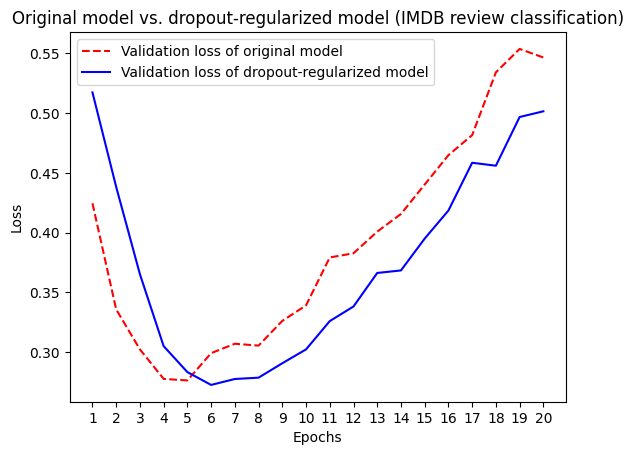

In [25]:
original_val_loss = history_original.history["val_loss"]
dropout_val_loss = history_dropout.history["val_loss"]
epochs = range(1, 21)
plt.plot(
    epochs,
    original_val_loss,
    "r--",
    label="Validation loss of original model",
)
plt.plot(
    epochs,
    dropout_val_loss,
    "b-",
    label="Validation loss of dropout-regularized model",
)
plt.title(
    "Original model vs. dropout-regularized model (IMDB review classification)"
)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.xticks(epochs)
plt.legend()
plt.show()